<a href="https://www.arduino.cc/"><img src="https://raw.githubusercontent.com/sandeepmistry/aimldevfest-workshop-2019/master/images/Arduino_logo_R_highquality.png" width=200/></a>
# Tiny ML on Arduino

## Setup Python Environment

The next cell sets up the dependencies in required for the notebook, run it.

In [12]:
# Setup environment
!apt-get -qq install xxd
!pip install pandas numpy matplotlib
!pip install tensorflow==2.0.0-rc1

ERROR: Could not find a version that satisfies the requirement tensorflow==2.0.0-rc1 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.0.0-rc1


# Upload Data

1. Open the panel on the left side of Colab by clicking on the __>__
1. Select the files tab
1. Drag `silence.csv`, `clap.csv`, `snap.csv` and `flex.csv` files from your computer to the tab to upload them into colab.

# Graph Data

We'll graph the pdm raw values from the input files by concatenating all the samples.
We can already see that there are similar pattern between samples of the same category.

/tmp/ipykernel_5133/41428118.py:19: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "g." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['pdm'], 'g.', label='x', linestyle='solid', marker=',')


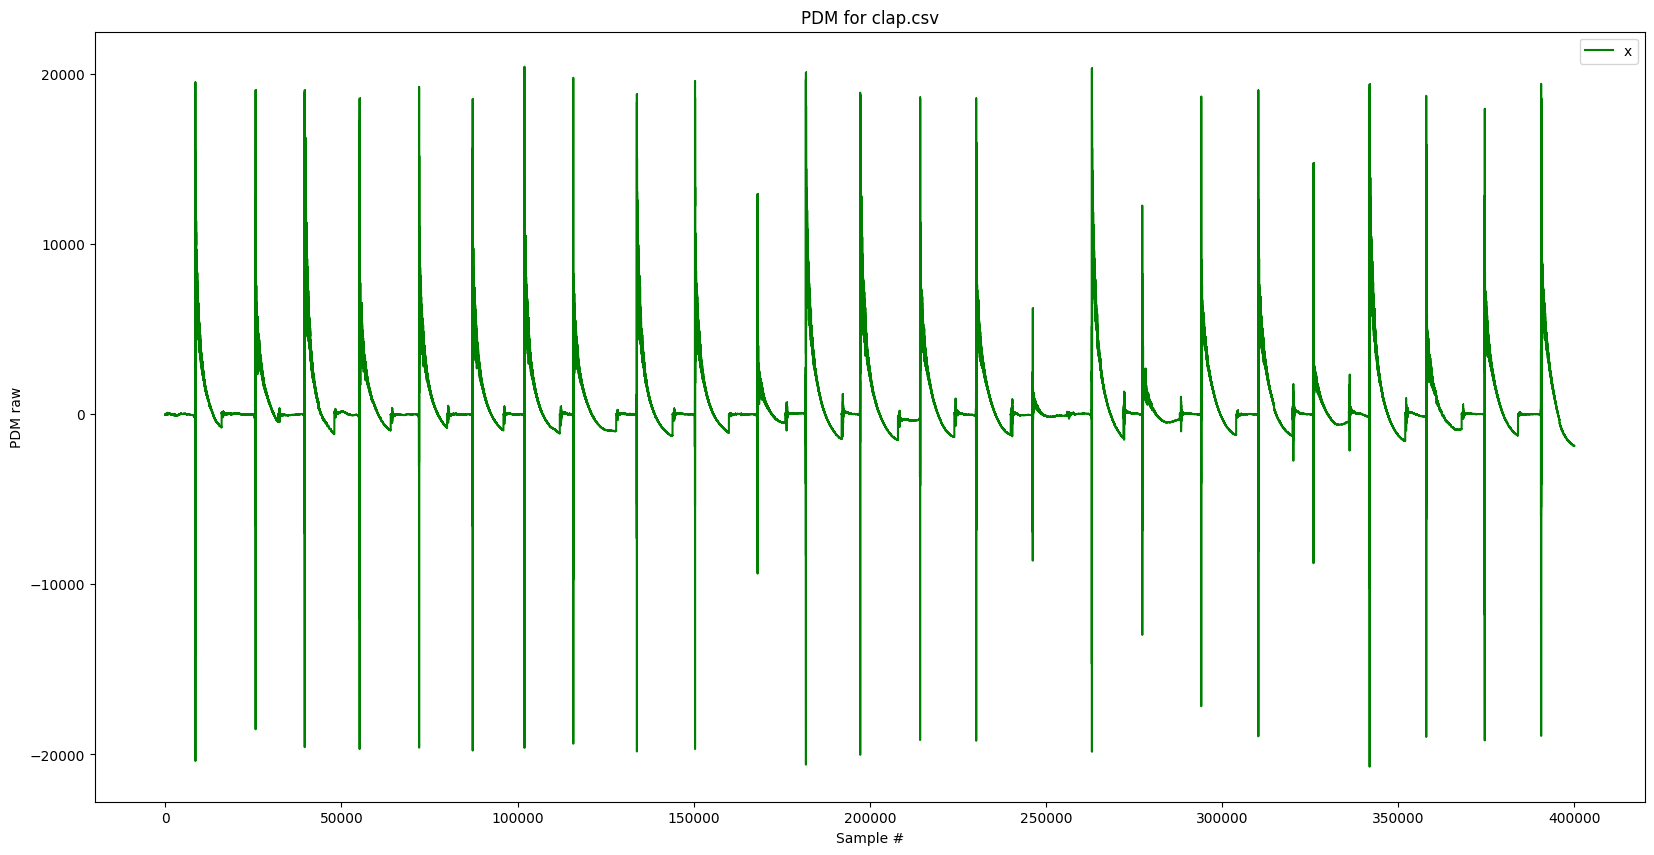

/tmp/ipykernel_5133/41428118.py:19: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "g." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['pdm'], 'g.', label='x', linestyle='solid', marker=',')


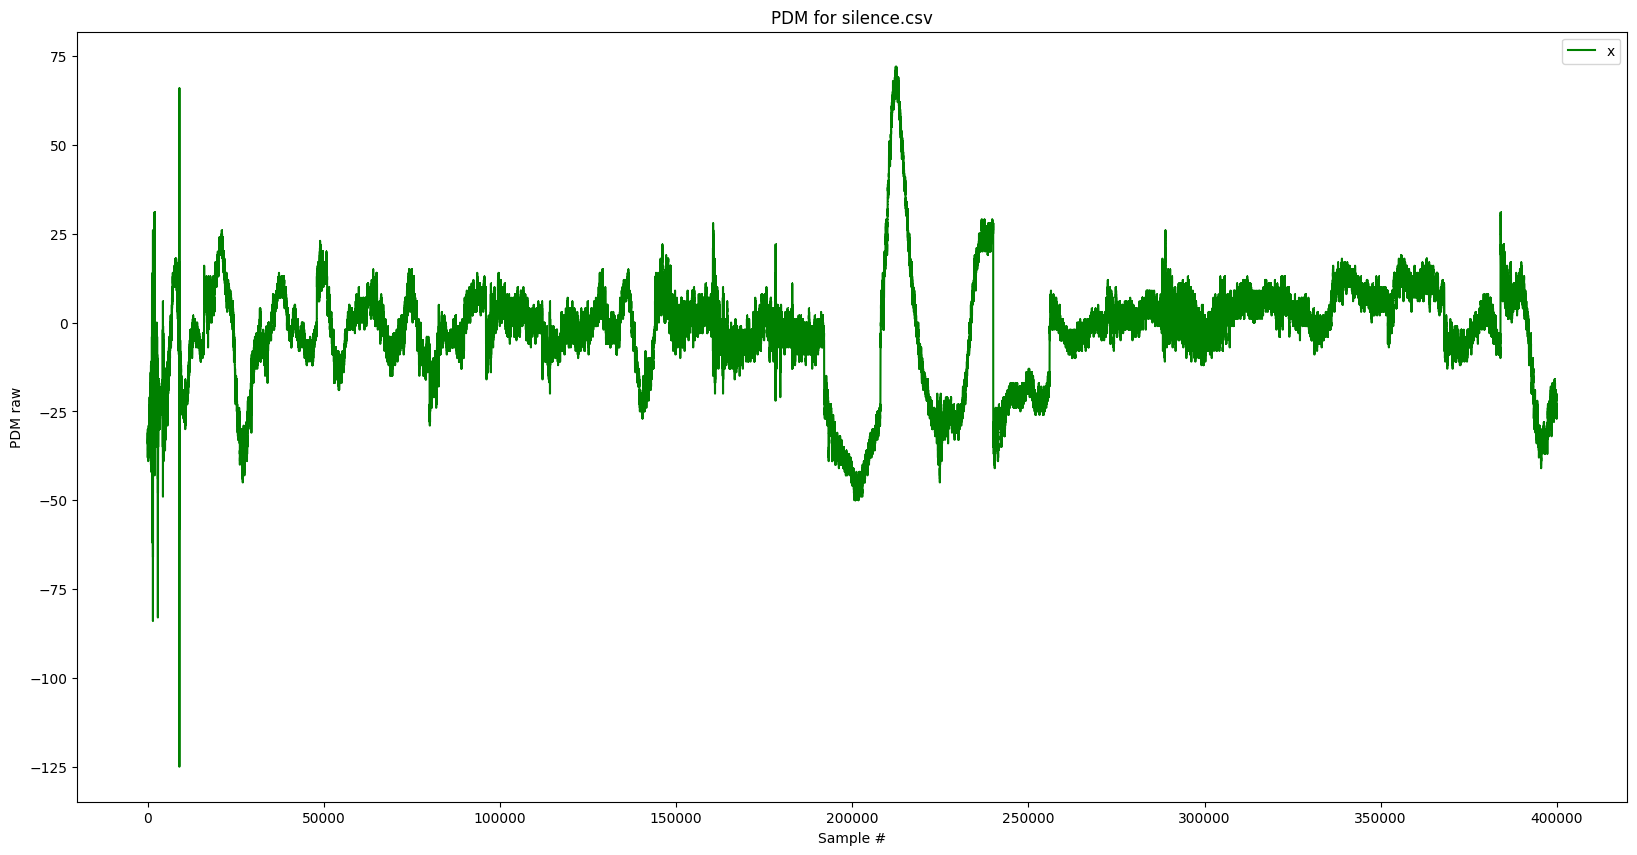

/tmp/ipykernel_5133/41428118.py:19: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "g." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['pdm'], 'g.', label='x', linestyle='solid', marker=',')


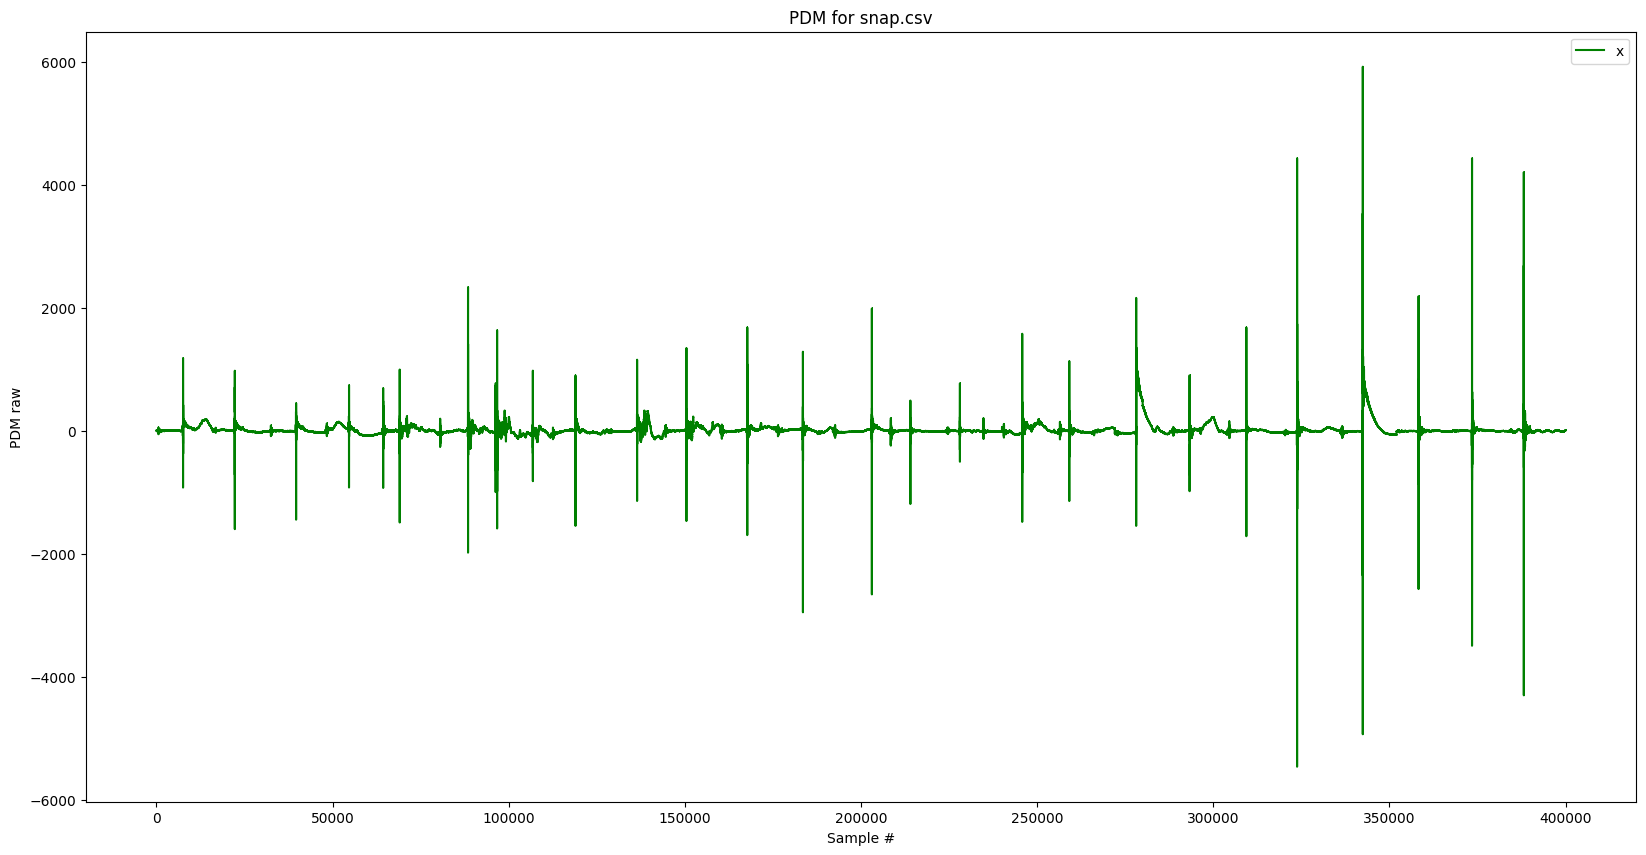

/tmp/ipykernel_5133/41428118.py:19: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "g." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['pdm'], 'g.', label='x', linestyle='solid', marker=',')


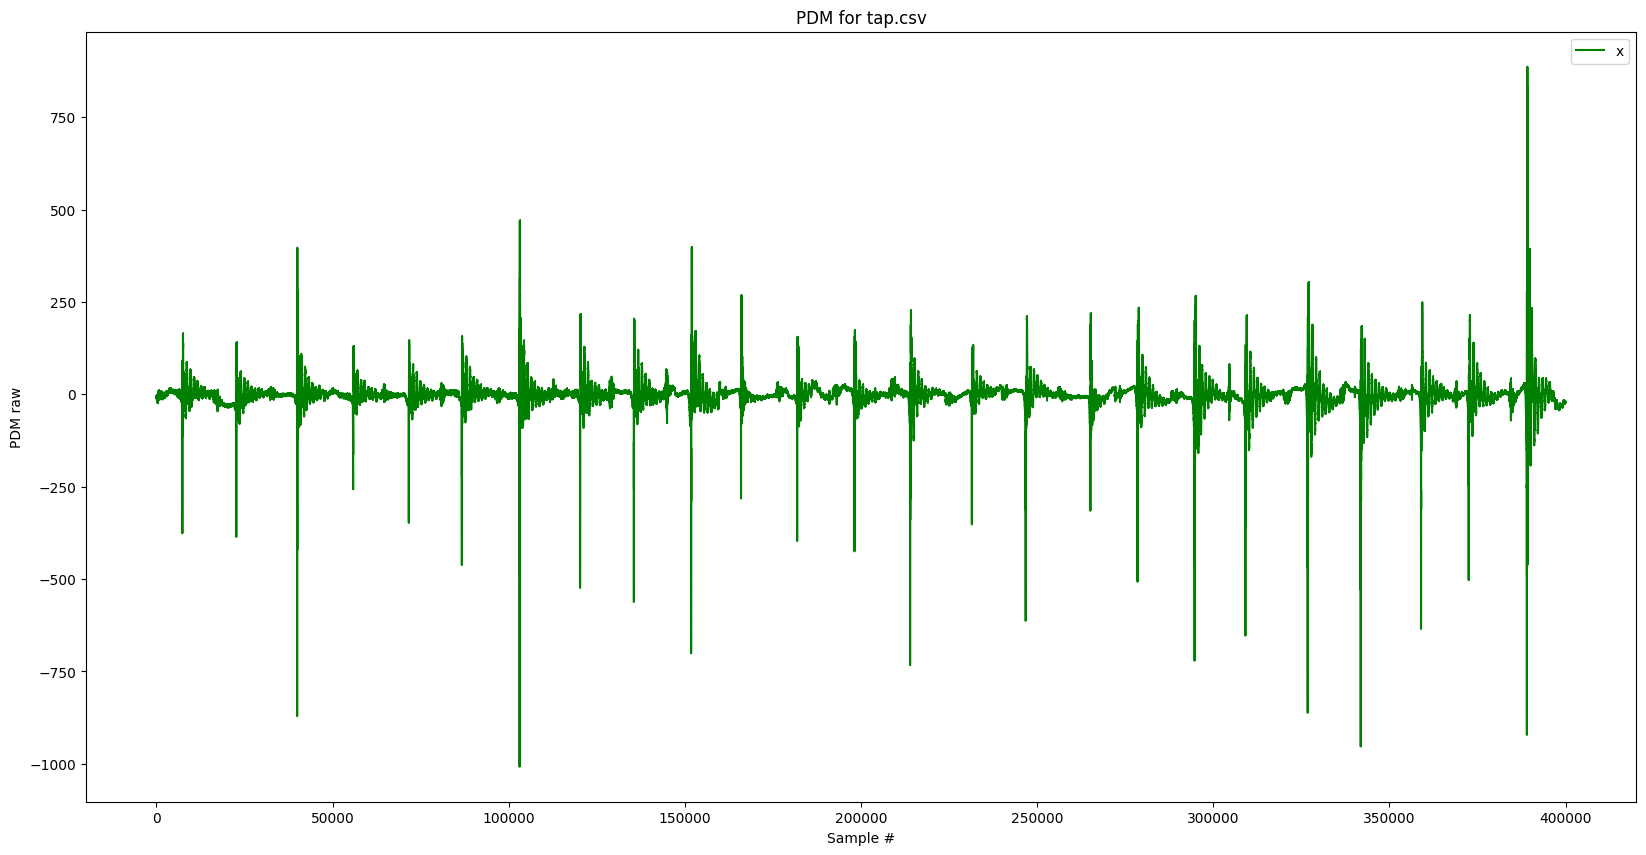

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

files = [
    "clap.csv",
    "silence.csv",
    "snap.csv",
    "tap.csv",
]

for f in files:
  df = pd.read_csv("/content/" + f)

  index = range(1, len(df['pdm']) + 1)

  plt.rcParams["figure.figsize"] = (20,10)

  plt.plot(index, df['pdm'], 'g.', label='x', linestyle='solid', marker=',')
  plt.title(f'PDM for {f}')
  plt.xlabel("Sample #")
  plt.ylabel("PDM raw")
  plt.legend()
  plt.show()


# Train Neural Network





# Parse and prepare the data

The next cell parses the csv files and transforms them to a format that will be used to train our neural network.

We will follow a standard pipeline for audio recognition to obtain MFCC from our raw PDM values:


1.   Audio sampling: done on device through PDM.
2.   Frame segmentation: we cut the 1 second sample into multiple overlapping frames, each with 256 samples.
3.   Pre-emphasis: we boost high frequencies before FFT to improve its quality.
3.   Hamming Window: the frame segmatation creates hard cuts at both fram edges, which are seen by FTT as high-frequency clicks. We employ the hamming window to taper the signal smoothly to zero at both ends.
4.   RFFT computation: We convert 256 time samples into 129 frequency bins using Real Fast Fourier Transform and using them to compute the power spectrum of the frame.
5.   Mel filter bank processing: we create 26 filters to group frequencies into bands based on human auditory perception.
6.   Log energy calculation: compute the energy for each filter using dot product, then using log function to compress everything from many orders of magnitude into a smaller interval.
7.   DCT computation: as adjacent mel filters share points we have some correlation between neighbouring, by employing dct-II we transform the filters into 26 independent components (coefficients).
8.   MFCC coefficient generation: we finnaly select only the most significant coefficients, which are C[1] - C[13]

This allows us to extract for each frame 13 coefficients, meaning that from 1 seconds recording (16'000 values) we end up with a 125 x 13 matrix that we can feed to the neural network.





In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

print(f"TensorFlow version = {tf.__version__}\n")

# Set a fixed random seed value, for reproducibility, this will allow us to get
# the same random numbers each time the notebook is run
SEED = 1337
np.random.seed(SEED)
tf.random.set_seed(SEED)

# the list of gestures that data is available for
GESTURES = [
    "clap",
    "silence",
    "snap",
    "tap",
]

FS = 16000
FRAME_LEN = 256
HOP_LEN = 128

NUM_MEL = 26
NUM_MFCC = 13
PREEMPH = 0.97
EPS = 1e-10

NUM_GESTURES = len(GESTURES)

# create a one-hot encoded matrix that is used in the output
ONE_HOT_ENCODED_GESTURES = np.eye(NUM_GESTURES)

inputs = []
outputs = []

# ===== PRECOMPUTED =====
def hamming_window(N):
    return 0.54 - 0.46 * np.cos(2 * np.pi * np.arange(N) / (N - 1))

def hz_to_mel(hz):
    return 2595 * np.log10(1 + hz / 700)

def mel_to_hz(mel):
    return 700 * (10**(mel / 2595) - 1)

def mel_filterbank():
    mel_low = hz_to_mel(300)
    mel_high = hz_to_mel(8000)

    # To get 26 Mel filters we will need 28 equally spaced Mel points
    # Corresponds to mel_pts[i] = 401 + i × (2840−401)/27 i=0..27
    mel_pts = np.linspace(mel_low, mel_high, NUM_MEL + 2)
    hz_pts = mel_to_hz(mel_pts)

    bins = np.floor((FRAME_LEN + 1) * hz_pts / FS).astype(int)

    fb = np.zeros((NUM_MEL, FRAME_LEN//2 + 1))

    for m in range(NUM_MEL):
        lo, ctr, hi = bins[m], bins[m+1], bins[m+2]

        for k in range(lo, ctr):
            fb[m, k] = (k - lo) / (ctr - lo)
        for k in range(ctr, hi):
            fb[m, k] = (hi - k) / (hi - ctr)

    return fb

def dct_matrix():
    M = NUM_MEL
    N = M
    matrix = np.zeros((N, M))

    for n in range(N):
        for m in range(M):
            matrix[n, m] = np.cos(np.pi * n * (m + 0.5) / M)

    return matrix

HAMMING_WINDOW = hamming_window(FRAME_LEN)
MEL_FB = mel_filterbank()
DCT = dct_matrix()

# ===== PIPELINE =====
def split_into_frames(x):
    frames = []
    for i in range(0, len(x) - FRAME_LEN, HOP_LEN):
        frames.append(x[i:i+FRAME_LEN])
    return np.array(frames)

def pre_emphasis(frame):
    x = np.zeros_like(frame)
    x[0] = frame[0]
    x[1:] = frame[1:] - PREEMPH * frame[:-1]
    return x

def mfcc(signal):
  frames = split_into_frames(signal)
  out = []

  for frame in frames:
         # Apply preemphasis
        x = pre_emphasis(frame)

        # Apply Hamming Window
        x = x * HAMMING_WINDOW

        # Real Fast Fourier Transform and power spectrum
        ftt = np.fft.rfft(x)
        power_ftt = np.abs(ftt) ** 2

        # current shape: (129,1)

        # Moving to Mel scale
        energy = np.matmul(MEL_FB, power_ftt)
        log_energy = np.log(energy + EPS)

        # current shape: (26,1)

        # DCT Computation
        coefficients = np.matmul(DCT, log_energy)

        # Compute the power spectrum of the frame
        choosen_coefficients = coefficients[1:NUM_MFCC+1]

        # current shape: (13,1)

        out.append(choosen_coefficients)

  return np.array(out)


# read each csv file and push an input and output
for gesture_index in range(NUM_GESTURES):
  gesture = GESTURES[gesture_index]
  print(f"Processing index {gesture_index} for gesture '{gesture}'.")

  output = ONE_HOT_ENCODED_GESTURES[gesture_index]

  df = pd.read_csv("/content/" + gesture + ".csv")
  df_array = df['pdm'].to_numpy()

  # calculate the number of gesture recordings in the file
  num_recordings = int(df.shape[0] / FS)

  print(f"\tThere are {num_recordings} recordings of the {gesture} gesture.")

  for i in range(num_recordings):
    # split the single recording into overlapped frames
    recording = df_array[i*FS:(i+1)*FS]

    # preprocess the data
    processed_frames = mfcc(recording)

    inputs.append(processed_frames)
    outputs.append(output)

# convert the list to numpy array
inputs = np.array(inputs)
outputs = np.array(outputs)

print("Data set parsing and preparation complete.")

def save_to_header(filename):
    with open(filename, 'w') as f:
        f.write("#ifndef PARAMS_H\n#define PARAMS_H\n\n")

        # 1. Hamming Window
        f.write(f"const float window[{len(HAMMING_WINDOW)}] = {{\n    ")
        f.write(", ".join([f"{x:.8f}f" for x in HAMMING_WINDOW]))
        f.write("\n};\n\n")

        # 2. Mel Filterbank (Flattened for arm_dot_prod)
        # Note: MEL_FB shape is (NUM_MEL, 129)
        mel_flat = MEL_FB.flatten()
        f.write(f"const float mel_fb[{len(mel_flat)}] = {{\n    ")
        # Writing values in small chunks for readability
        for i, x in enumerate(mel_flat):
            f.write(f"{x:.8f}f, ")
            if (i + 1) % 8 == 0: f.write("\n    ")
        f.write("\n};\n\n")

        # 3. DCT Matrix (Flattened)
        # Note: DCT shape is (NUM_MFCC, NUM_MEL)
        dct_flat = DCT.flatten()
        f.write(f"const float dct[{len(dct_flat)}] = {{\n    ")
        for i, x in enumerate(dct_flat):
            f.write(f"{x:.8f}f, ")
            if (i + 1) % 8 == 0: f.write("\n    ")
        f.write("\n};\n\n")

        f.write("#endif // PARAMS_H\n")

save_to_header("precomputed_params.h")

print("Precomputed matrices prepared.")

TensorFlow version = 2.19.0

Processing index 0 for gesture 'clap'.
	There are 25 recordings of the clap gesture.
Processing index 1 for gesture 'silence'.
	There are 25 recordings of the silence gesture.
Processing index 2 for gesture 'snap'.
	There are 25 recordings of the snap gesture.
Processing index 3 for gesture 'tap'.
	There are 25 recordings of the tap gesture.
Data set parsing and preparation complete.
Precomputed matrices prepared.


## Randomize and split the input and output pairs for training

Randomly split input and output pairs into sets of data: 60% for training, 20% for validation, and 20% for testing.

  - the training set is used to train the model
  - the validation set is used to measure how well the model is performing during training
  - the testing set is used to test the model after training

In [15]:
# Randomize the order of the inputs, so they can be evenly distributed for training, testing, and validation
# https://stackoverflow.com/a/37710486/2020087
num_inputs = len(inputs)
randomize = np.arange(num_inputs)
np.random.shuffle(randomize)

# Swap the consecutive indexes (0, 1, 2, etc) with the randomized indexes
inputs = inputs[randomize]
outputs = outputs[randomize]

# Split the recordings (group of samples) into three sets: training, testing and validation
TRAIN_SPLIT = int(0.6 * num_inputs)
TEST_SPLIT = int(0.2 * num_inputs + TRAIN_SPLIT)

inputs_train, inputs_test, inputs_validate = np.split(inputs, [TRAIN_SPLIT, TEST_SPLIT])
outputs_train, outputs_test, outputs_validate = np.split(outputs, [TRAIN_SPLIT, TEST_SPLIT])

print("Data set randomization and splitting complete.")

Data set randomization and splitting complete.


## Build & Train the Model

Build and train a [TensorFlow](https://www.tensorflow.org) model using the high-level [Keras](https://www.tensorflow.org/guide/keras) API.

In [16]:
import tensorflow as tf

model = tf.keras.models.Sequential([
    # Input shape: (Time=123, MFCC=13, Channels=1)
    tf.keras.layers.Input(shape=(123, 13, 1)),

    # Layer 1: Smaller filter count to save space
    tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Layer 2: Depthwise Separable Convolution
    tf.keras.layers.SeparableConv2D(16, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Creates only 16 features.
    tf.keras.layers.GlobalAveragePooling2D(),

    # Final Classification Layer
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(NUM_GESTURES, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    inputs_train,
    outputs_train,
    epochs=200,
    batch_size=8,
    validation_data=(inputs_validate, outputs_validate),
    shuffle=True
)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 144ms/step - accuracy: 0.2333 - loss: 1.6167 - val_accuracy: 0.1000 - val_loss: 1.4773
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.2333 - loss: 1.5918 - val_accuracy: 0.1000 - val_loss: 1.4327
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.2667 - loss: 1.4101 - val_accuracy: 0.1500 - val_loss: 1.4218
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.3333 - loss: 1.4229 - val_accuracy: 0.1500 - val_loss: 1.4253
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.4500 - loss: 1.3757 - val_accuracy: 0.1500 - val_loss: 1.4375
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.3000 - loss: 1.4354 - val_accuracy: 0.1500 - val_loss: 1.4390
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.2500 - loss: 1.3988 - val_accuracy: 0.1500 - val_loss: 1.4301
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.4000 - loss: 1.3124 - val_accuracy: 0.1500 - val_

## Verify

Graph the models performance vs validation.


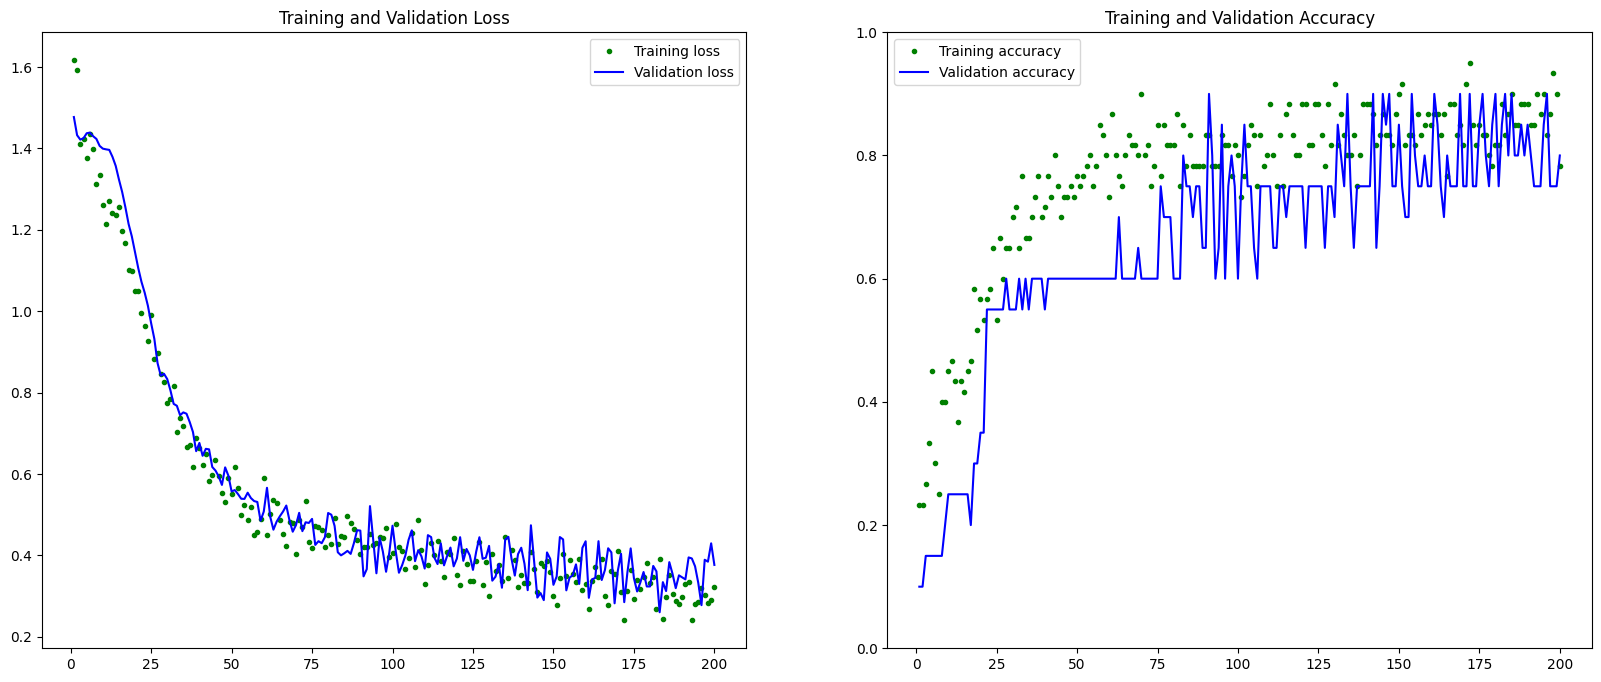

In [17]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot Loss
epochs = range(1, len(history.history['loss']) + 1)
ax1.plot(epochs, history.history['loss'], 'g.', label='Training loss')
ax1.plot(epochs, history.history['val_loss'], 'b', label='Validation loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()

# Plot Accuracy
ax2.plot(epochs, history.history['accuracy'], 'g.', label='Training accuracy')
ax2.plot(epochs, history.history['val_accuracy'], 'b', label='Validation accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.set_ylim([0, 1])
ax2.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


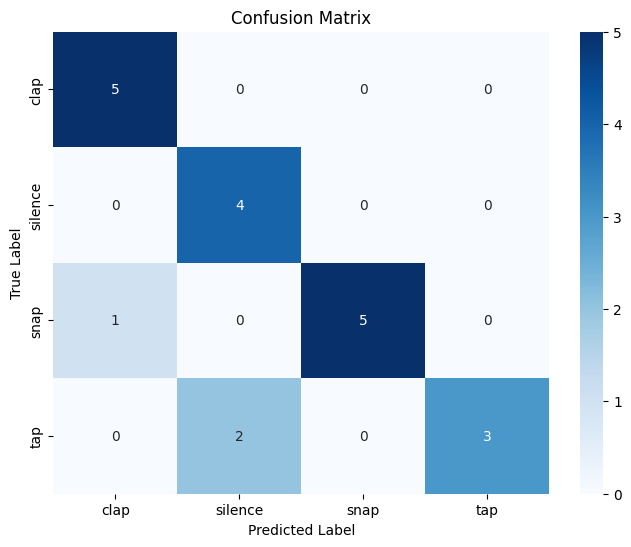

In [18]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

predictions = model.predict(inputs_test)
# Get the predicted labels (index of the highest probability)
predicted_labels = predictions.argmax(axis=1)
# Get the actual labels
actual_labels = outputs_test.argmax(axis=1)

# Compute the confusion matrix, explicitly providing all possible labels
cm = confusion_matrix(actual_labels, predicted_labels, labels=range(NUM_GESTURES))

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GESTURES, yticklabels=GESTURES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [19]:
loss, accuracy = model.evaluate(inputs_test, outputs_test)
print(f"Loss on the test data: {loss:.4f}")
print(f"Accuracy on the test data: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8500 - loss: 0.2954
Loss on the test data: 0.2954
Accuracy on the test data: 0.8500


# Convert the Trained Model to Tensor Flow Lite

The next cell converts the model to TFlite format. The size in bytes of the model is also printed out.

In [20]:
# Convert the model to the TensorFlow Lite format without quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the model to disk
open("gesture_model.tflite", "wb").write(tflite_model)

import os
basic_model_size = os.path.getsize("gesture_model.tflite")
print("Model is %d bytes" % basic_model_size)



Saved artifact at '/tmp/tmpq_x6nbqu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 123, 13, 1), dtype=tf.float32, name='keras_tensor_9')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  136661452958864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136661452957520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136661506551888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136661445363088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136661445362320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136661445363280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136661445362128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136661445364048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136661445363856: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model is 6528 bytes


## Encode the Model in an Arduino Header File

The next cell creates a constant byte array that contains the TFlite model. Import it as a tab with the sketch below.

In [21]:
!echo "const unsigned char model[] = {" > /content/model.h
!cat gesture_model.tflite | xxd -i      >> /content/model.h
!echo "};"                              >> /content/model.h

import os
model_h_size = os.path.getsize("model.h")
print(f"Header file, model.h, is {model_h_size:,} bytes.")
print("\nOpen the side panel (refresh if needed). Double click model.h to download the file.")

Header file, model.h, is 40,290 bytes.

Open the side panel (refresh if needed). Double click model.h to download the file.


# Classifying IMU Data

Now it's time to switch back to the tutorial instructions and run our new model on the Arduino Nano 33 BLE Sense to classify the accelerometer and gyroscope data.
